# 配图生成脚本

运行此 notebook 将在 `figures/` 目录下生成 `blog.md` 中引用的所有配图。

**依赖**：`numpy`、`matplotlib`

```bash
pip install numpy matplotlib
```

按顺序运行全部 Cell，确保 `figures/` 目录与 `blog.md` 在同一文件夹即可正常显示图片。

| Cell | 生成文件 | 对应章节 |
|------|---------|---------|
| 初始化 | — | — |
| 图1 | `fig_distance_motivation.png` | 第一节：为什么要有距离 |
| 图2 | `fig_distance_paths.png` | 第二节：三种经典距离 |
| 图3 | `fig_cosine.png` | 第二节：余弦相似度 |
| 图4 | `norm_unit_balls.png` | 第三节：三种范数的单位球 |
| 图5 | `lasso_ridge_geometry.png` | 第四节：Lasso vs Ridge |


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import os

os.makedirs('figures', exist_ok=True)

# 中文支持
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams.update({
    'font.family': ['SimHei', 'Arial'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': '#FAFAFA',
})

C = {
    'L1':     '#E74C3C',
    'L2':     '#2980B9',
    'Linf':   '#27AE60',
    'contour':'#95A5A6',
    'bg':     '#FAFAFA',
    'cls_a':  '#3498DB',
    'cls_b':  '#E74C3C',
    'center': '#F39C12',
    'gray':   '#7F8C8D',
}

def lp_unit_circle(p, n=2000):
    """二维 Lp 单位球边界的参数化点集。"""
    angles = np.linspace(0, 2 * np.pi, n)
    xs, ys = np.cos(angles), np.sin(angles)
    norms = (np.abs(xs)**p + np.abs(ys)**p) ** (1 / p)
    return xs / norms, ys / norms

print("环境就绪 ✓")


环境就绪 ✓


## 图1：K-Means 与 SVM 中的距离（氛围图）

左图突出簇内距离 vs 簇间距离；右图突出 SVM 间隔（margin）。


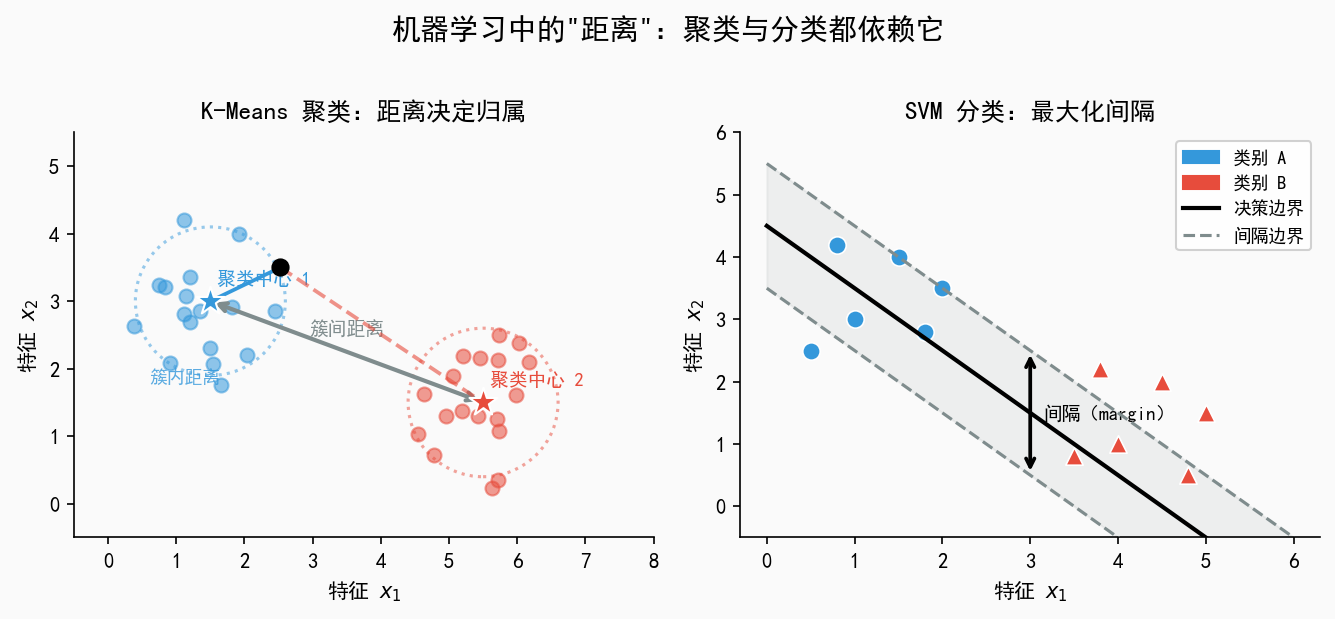

✓ 保存至 figures/fig_distance_motivation.png


In [7]:
np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.patch.set_facecolor(C['bg'])

# ── 左图：K-Means ──────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(C['bg'])

# 两个簇
c1 = np.array([1.5, 3.0])
c2 = np.array([5.5, 1.5])
pts1 = c1 + np.random.randn(18, 2) * 0.65
pts2 = c2 + np.random.randn(18, 2) * 0.65

ax.scatter(*pts1.T, color=C['cls_a'], alpha=0.55, s=45, zorder=3)
ax.scatter(*pts2.T, color=C['cls_b'], alpha=0.55, s=45, zorder=3)

# 聚类中心
ax.scatter(*c1, color=C['cls_a'], s=200, marker='*', zorder=5, edgecolors='white', linewidths=1)
ax.scatter(*c2, color=C['cls_b'], s=200, marker='*', zorder=5, edgecolors='white', linewidths=1)
ax.text(c1[0]+0.1, c1[1]+0.25, '聚类中心 1', fontsize=9, color=C['cls_a'])
ax.text(c2[0]+0.1, c2[1]+0.25, '聚类中心 2', fontsize=9, color=C['cls_b'])

# 一个点到两个中心的距离线
p_sample = pts1[3]
ax.plot([p_sample[0], c1[0]], [p_sample[1], c1[1]],
        color=C['cls_a'], lw=1.8, linestyle='-', zorder=4)
ax.plot([p_sample[0], c2[0]], [p_sample[1], c2[1]],
        color=C['cls_b'], lw=1.8, linestyle='--', alpha=0.6, zorder=4)
ax.scatter(*p_sample, color='black', s=60, zorder=6)

# 簇间距离箭头
mid = (c1 + c2) / 2
ax.annotate('', xy=c2, xytext=c1,
            arrowprops=dict(arrowstyle='<->', color=C['gray'], lw=2))
ax.text(mid[0], mid[1]+0.25, '簇间距离', ha='center', fontsize=9, color=C['gray'])

# 簇内距离示意圆
for center, color in [(c1, C['cls_a']), (c2, C['cls_b'])]:
    circle = plt.Circle(center, 1.1, color=color, fill=False,
                        linestyle=':', linewidth=1.5, alpha=0.5)
    ax.add_patch(circle)

ax.text(c1[0]-0.9, c1[1]-1.2, '簇内距离', fontsize=8.5, color=C['cls_a'], alpha=0.8)

ax.set_xlim(-0.5, 8); ax.set_ylim(-0.5, 5.5)
ax.set_title('K-Means 聚类：距离决定归属', fontsize=12, fontweight='bold')
ax.set_xlabel('特征 $x_1$', fontsize=10); ax.set_ylabel('特征 $x_2$', fontsize=10)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# ── 右图：SVM ──────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(C['bg'])

# 两类线性可分的点
pts_a = np.array([[1,3],[1.5,4],[0.5,2.5],[2,3.5],[0.8,4.2],[1.8,2.8]])
pts_b = np.array([[4,1],[4.5,2],[3.5,0.8],[5,1.5],[3.8,2.2],[4.8,0.5]])

ax2.scatter(*pts_a.T, color=C['cls_a'], s=70, zorder=4, edgecolors='white', linewidths=0.8)
ax2.scatter(*pts_b.T, color=C['cls_b'], s=70, zorder=4, marker='^',
            edgecolors='white', linewidths=0.8)

# 决策边界及间隔线：w·x + b = 0  →  x2 = -x1 + 4.5
x_line = np.array([0, 6])
boundary   = -x_line + 4.5
margin_pos = -x_line + 5.5
margin_neg = -x_line + 3.5

ax2.plot(x_line, boundary,   color='black',  lw=2,   label='决策边界', zorder=5)
ax2.plot(x_line, margin_pos, color=C['gray'],lw=1.5, linestyle='--', zorder=4)
ax2.plot(x_line, margin_neg, color=C['gray'],lw=1.5, linestyle='--', zorder=4)

# 填充间隔区域
ax2.fill_between(x_line, margin_neg, margin_pos, alpha=0.10, color=C['gray'])

# 间隔宽度双箭头
mx = 3.0
my_b = -mx + 5.5
my_n = -mx + 3.5
ax2.annotate('', xy=(mx, my_b), xytext=(mx, my_n),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.8))
ax2.text(mx + 0.15, (my_b + my_n)/2, '间隔（margin）',
         fontsize=9, va='center', color='black')

ax2.set_xlim(-0.3, 6.3); ax2.set_ylim(-0.5, 6)
ax2.set_title('SVM 分类：最大化间隔', fontsize=12, fontweight='bold')
ax2.set_xlabel('特征 $x_1$', fontsize=10); ax2.set_ylabel('特征 $x_2$', fontsize=10)

legend_elements = [
    mpatches.Patch(color=C['cls_a'], label='类别 A'),
    mpatches.Patch(color=C['cls_b'], label='类别 B'),
    plt.Line2D([0],[0], color='black', lw=2, label='决策边界'),
    plt.Line2D([0],[0], color=C['gray'], lw=1.5, linestyle='--', label='间隔边界'),
]
ax2.legend(handles=legend_elements, fontsize=8.5, loc='upper right', framealpha=0.9)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

fig.suptitle('机器学习中的"距离"：聚类与分类都依赖它',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_distance_motivation.png', dpi=150)
plt.show()
print("✓ 保存至 figures/fig_distance_motivation.png")


## 图2：三种距离路径示意图

同一对点 A、B，三种走法：欧氏（直线）、曼哈顿（折线）、切比雪夫（标注最大分量）。


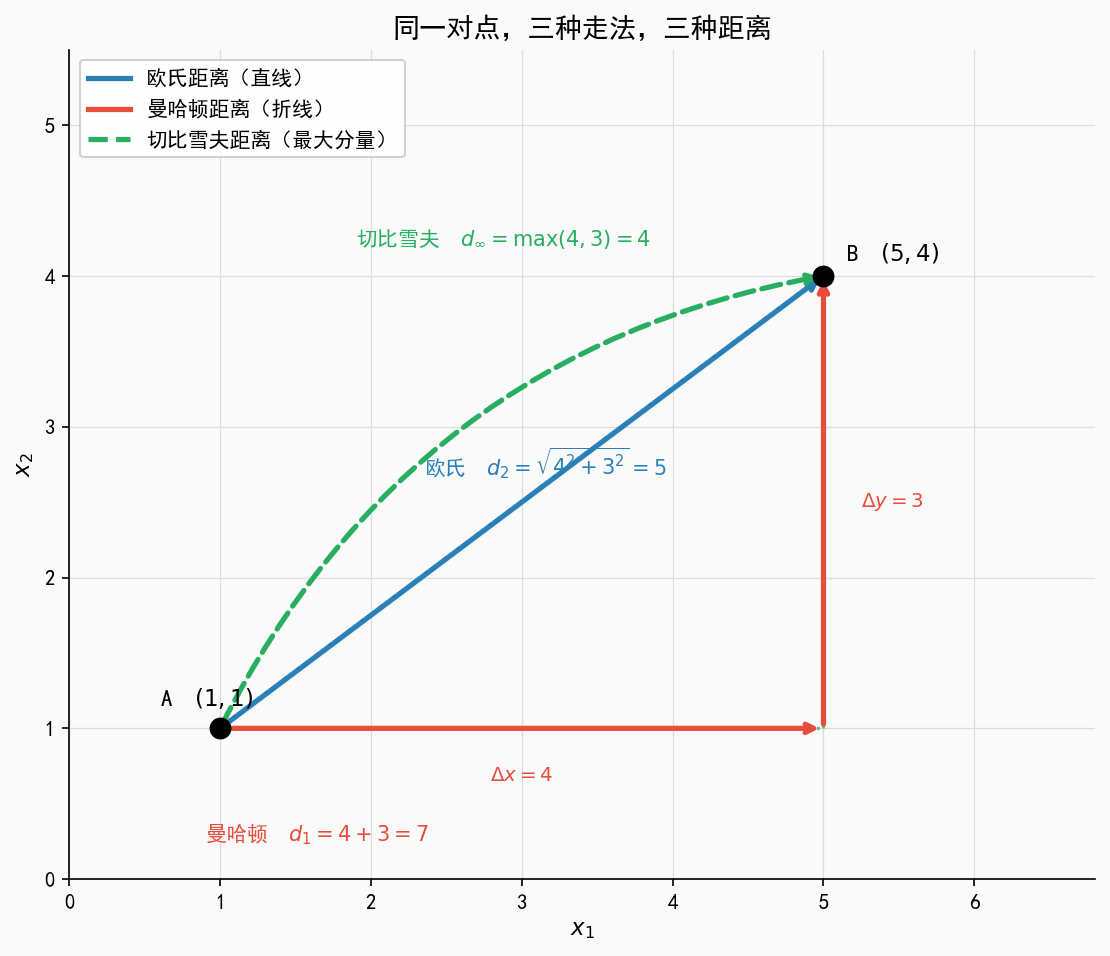

✓ 保存至 figures/fig_distance_paths.png


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
fig.patch.set_facecolor(C['bg'])
ax.set_facecolor(C['bg'])

A = np.array([1.0, 1.0])
B = np.array([5.0, 4.0])
dx = B[0] - A[0]   # 4
dy = B[1] - A[1]   # 3

# ── 欧氏：直线 ──────────────────────────────────────────────────────────────
ax.annotate('', xy=B, xytext=A,
            arrowprops=dict(arrowstyle='->', color=C['L2'], lw=2.5))
mid_e = (A + B) / 2
ax.text(mid_e[0]-0.65, mid_e[1]+0.18,
        f'欧氏  $d_2 = \sqrt{{{int(dx)}^2+{int(dy)}^2}} = 5$',
        fontsize=10, color=C['L2'], fontweight='bold')

# ── 曼哈顿：先横后竖 ────────────────────────────────────────────────────────
corner = np.array([B[0], A[1]])
ax.annotate('', xy=corner, xytext=A,
            arrowprops=dict(arrowstyle='->', color=C['L1'], lw=2.5,
                            connectionstyle='arc3,rad=0'))
ax.annotate('', xy=B, xytext=corner,
            arrowprops=dict(arrowstyle='->', color=C['L1'], lw=2.5,
                            connectionstyle='arc3,rad=0'))
ax.text(A[0] + dx/2, A[1] - 0.35, f'$\Delta x = {int(dx)}$',
        ha='center', fontsize=9.5, color=C['L1'])
ax.text(B[0] + 0.25, A[1] + dy/2, f'$\Delta y = {int(dy)}$',
        va='center', fontsize=9.5, color=C['L1'])
ax.text(A[0]-0.1, A[1]-0.75,
        f'曼哈顿  $d_1 = {int(dx)}+{int(dy)} = 7$',
        fontsize=10, color=C['L1'], fontweight='bold')

# ── 切比雪夫：标注最大分量 ────────────────────────────────────────────────
ax.plot([A[0], B[0]], [A[1], A[1]], color=C['Linf'],
        lw=1.5, linestyle=':', alpha=0.7)
ax.plot([B[0], B[0]], [A[1], B[1]], color=C['Linf'],
        lw=1.5, linestyle=':', alpha=0.7)
ax.annotate('', xy=B, xytext=A,
            arrowprops=dict(arrowstyle='->', color=C['Linf'], lw=2.5,
                            linestyle='dashed',
                            connectionstyle='arc3,rad=-0.25'))
ax.text(A[0]+0.9, B[1]+0.2,
        f'切比雪夫  $d_\infty = \max({int(dx)},{int(dy)}) = {int(dx)}$',
        fontsize=10, color=C['Linf'], fontweight='bold')

# ── 点 A、B ──────────────────────────────────────────────────────────────────
for pt, label in [(A, 'A  $(1, 1)$'), (B, 'B  $(5, 4)$')]:
    ax.scatter(*pt, color='black', s=90, zorder=6)
    offset = (-0.4, 0.15) if label.startswith('A') else (0.15, 0.1)
    ax.text(pt[0]+offset[0], pt[1]+offset[1], label, fontsize=11, fontweight='bold')

# ── 辅助网格 ─────────────────────────────────────────────────────────────────
for xi in range(0, 7):
    ax.axvline(xi, color='#DDD', lw=0.6, zorder=0)
for yi in range(0, 6):
    ax.axhline(yi, color='#DDD', lw=0.6, zorder=0)

ax.set_xlim(0, 6.8); ax.set_ylim(0, 5.5)
ax.set_aspect('equal')
ax.set_xlabel('$x_1$', fontsize=11); ax.set_ylabel('$x_2$', fontsize=11)
ax.set_title('同一对点，三种走法，三种距离', fontsize=13, fontweight='bold')

legend_items = [
    plt.Line2D([0],[0], color=C['L2'],   lw=2.5, label='欧氏距离（直线）'),
    plt.Line2D([0],[0], color=C['L1'],   lw=2.5, label='曼哈顿距离（折线）'),
    plt.Line2D([0],[0], color=C['Linf'], lw=2.5, linestyle='dashed', label='切比雪夫距离（最大分量）'),
]
ax.legend(handles=legend_items, fontsize=10, loc='upper left', framealpha=0.9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('figures/fig_distance_paths.png', dpi=150)
plt.show()
print("✓ 保存至 figures/fig_distance_paths.png")


## 图3：余弦相似度示意图

四组向量对，展示不同夹角对应的余弦值。图形力求简洁，核心信息是「方向决定相似度」。


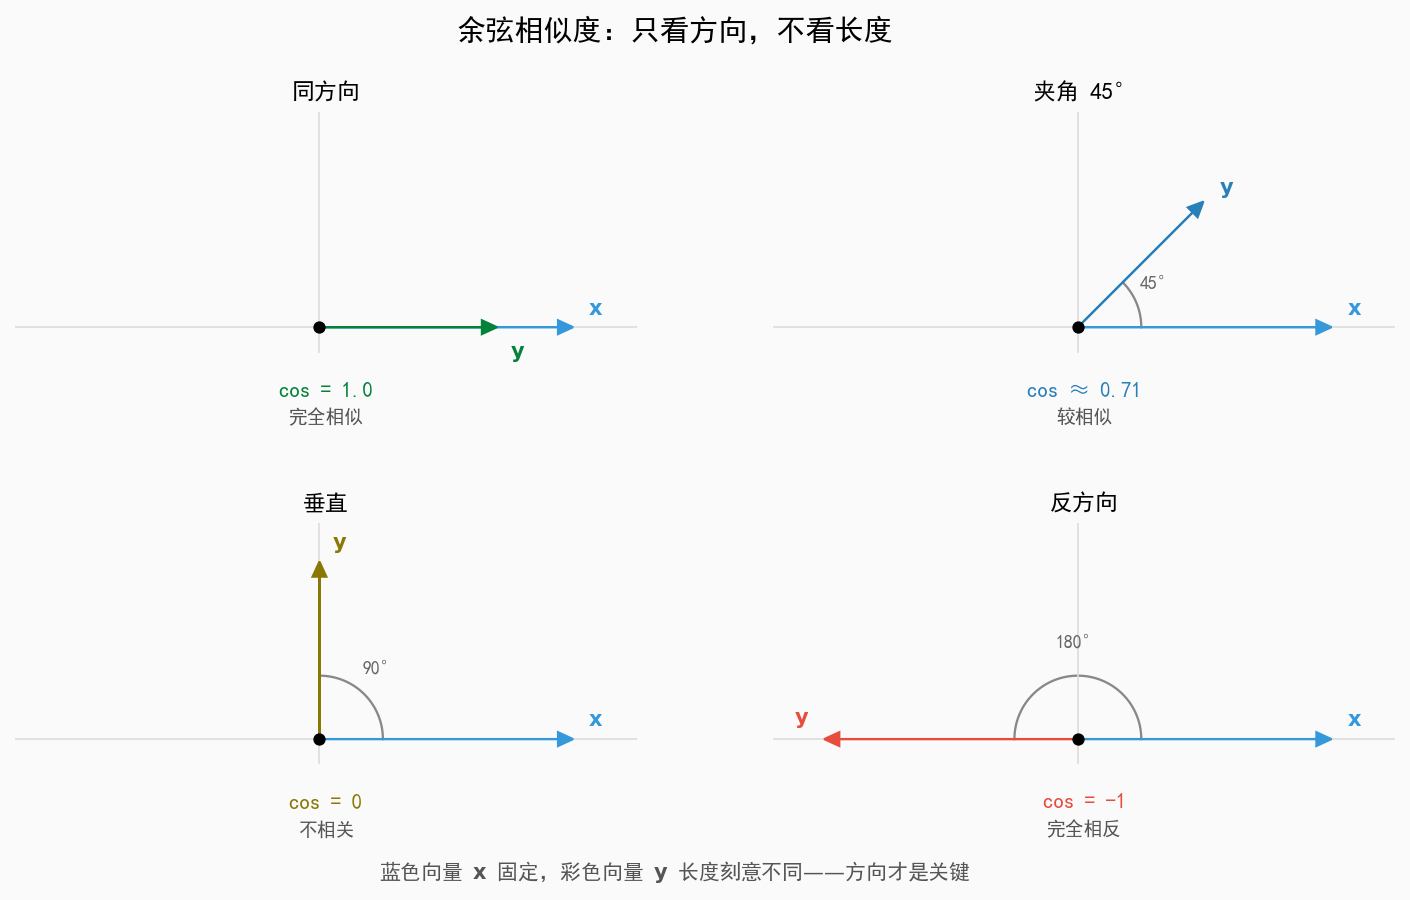

✓ 保存至 figures/fig_cosine.png


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.patch.set_facecolor(C['bg'])
axes = axes.ravel()

cases = [
    (0,   "#048239", '同方向',   'cos = 1.0',  '完全相似'),
    (45,  '#2980B9', '夹角 45°', 'cos ≈ 0.71', '较相似'),
    (90,  "#897804", '垂直',     'cos = 0',    '不相关'),
    (180, '#E74C3C', '反方向',   'cos = -1',   '完全相反'),
]

for ax, (angle_deg, color, title, cos_val, desc) in zip(axes, cases):
    ax.set_facecolor(C['bg'])
    angle = np.radians(angle_deg)

    # 基准向量与比较向量
    v1 = np.array([1.0, 0.0])
    v2_len = 0.7 if angle_deg != 180 else 1.0
    v2 = v2_len * np.array([np.cos(angle), np.sin(angle)])

    # 向量
    arrow_kw = dict(head_width=0.055, head_length=0.06, length_includes_head=True, zorder=5)
    ax.arrow(0, 0, v1[0], v1[1], color=C['cls_a'], **arrow_kw)
    ax.arrow(0, 0, v2[0], v2[1], color=color, **arrow_kw)

    # 夹角弧与角度标签
    if angle_deg > 0:
        theta_arc = np.linspace(0, angle, 80)
        r_arc = 0.25
        ax.plot(r_arc * np.cos(theta_arc), r_arc * np.sin(theta_arc), color='#888', lw=1.1)

        label_angle = angle / 2
        ax.text(0.34 * np.cos(label_angle),
                0.34 * np.sin(label_angle) + 0.02,
                f'{angle_deg}°', fontsize=8.5, ha='center', color='#666')

    # 向量标签（按角度单独微调，减少重叠）
    x_pos = (v1[0] + 0.06, v1[1] + 0.05)
    y_label_pos = {
        0:   (v2[0] + 0.05, v2[1] - 0.12),
        45:  (v2[0] + 0.06, v2[1] + 0.03),
        90:  (v2[0] + 0.05, v2[1] + 0.05),
        180: (v2[0] - 0.12, v2[1] + 0.06),
    }[angle_deg]

    ax.text(*x_pos, r'$\mathbf{x}$', fontsize=10, color=C['cls_a'], fontweight='bold')
    ax.text(*y_label_pos, r'$\mathbf{y}$', fontsize=10, color=color, fontweight='bold')

    # 原点
    ax.scatter(0, 0, color='black', s=24, zorder=6)

    # 坐标与标题
    ax.set_xlim(-1.2, 1.25)
    ax.set_ylim(-0.1, 0.85)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)

    # 说明文字放到坐标轴下方（避免与图形重叠）
    ax.text(0.5, -0.12, cos_val, ha='center', va='top',
            fontsize=10, color=color, fontweight='bold',
            transform=ax.transAxes, clip_on=False)
    ax.text(0.5, -0.23, desc, ha='center', va='top',
            fontsize=9, color='#555',
            transform=ax.transAxes, clip_on=False)

    ax.axhline(0, color='#DDD', lw=0.8)
    ax.axvline(0, color='#DDD', lw=0.8)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

fig.suptitle('余弦相似度：只看方向，不看长度', fontsize=14, fontweight='bold', y=0.98)
fig.text(0.5, 0.02,
         r'蓝色向量 $\mathbf{x}$ 固定，彩色向量 $\mathbf{y}$ 长度刻意不同——方向才是关键',
         ha='center', fontsize=10, color='#555')

plt.subplots_adjust(left=0.06, right=0.98, top=0.90, bottom=0.12, wspace=0.22, hspace=0.42)
plt.savefig('figures/fig_cosine.png', dpi=150)
plt.show()
print("✓ 保存至 figures/fig_cosine.png")


## 图4：三种范数的单位球（二维截面）

$\|\mathbf{x}\|_p = 1$ 时的点集形状：菱形、圆形、正方形。


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5196\3180626290.py:39: RuntimeWarning: divide by zero encountered in divide
  return xs / norms, ys / norms


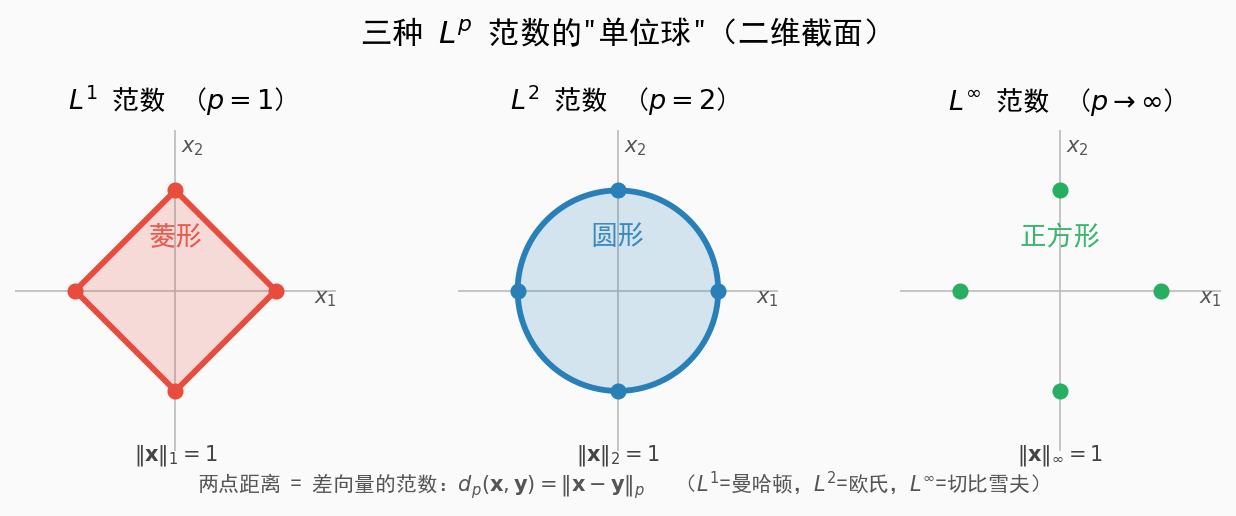

✓ 保存至 figures/norm_unit_balls.png


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
fig.patch.set_facecolor(C['bg'])

configs = [
    (r'$L^1$ 范数  ($p=1$)',               r'$\|\mathbf{x}\|_1 = 1$',        '菱形',   C['L1'],   1),
    (r'$L^2$ 范数  ($p=2$)',               r'$\|\mathbf{x}\|_2 = 1$',        '圆形',   C['L2'],   2),
    (r'$L^\infty$ 范数  ($p\to\infty$)', r'$\|\mathbf{x}\|_\infty = 1$', '正方形', C['Linf'], 1e6),
]

for ax, (title, subtitle, shape_name, color, p) in zip(axes, configs):
    ax.set_facecolor(C['bg'])
    xc, yc = lp_unit_circle(p)
    ax.fill(xc, yc, alpha=0.18, color=color)
    ax.plot(xc, yc, color=color, linewidth=2.8)

    ax.axhline(0, color='#BBB', lw=0.8, zorder=0)
    ax.axvline(0, color='#BBB', lw=0.8, zorder=0)

    for kx, ky in [(1,0),(0,1),(-1,0),(0,-1)]:
        ax.scatter(kx, ky, color=color, s=45, zorder=5)

    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.text(0, -1.52, subtitle, ha='center', va='top', fontsize=10, color='#444')
    ax.text(1.38, -0.12, '$x_1$', fontsize=10, color='#555')
    ax.text(0.06,  1.38, '$x_2$', fontsize=10, color='#555')
    ax.text(0, 0.55, shape_name, ha='center', va='center',
            fontsize=13, color=color, fontweight='bold', alpha=0.9)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values(): spine.set_visible(False)

fig.suptitle(r'三种 $L^p$ 范数的"单位球"（二维截面）',
             fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, -0.04,
         r'两点距离 = 差向量的范数：$d_p(\mathbf{x},\mathbf{y})=\|\mathbf{x}-\mathbf{y}\|_p$'
         r'   （$L^1$=曼哈顿，$L^2$=欧氏，$L^\infty$=切比雪夫）',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.savefig('figures/norm_unit_balls.png', dpi=150)
plt.show()
print("✓ 保存至 figures/norm_unit_balls.png")


## 图5：Lasso vs Ridge 几何解释

约束域与损失函数等高线相切，解释为什么 Lasso 产生稀疏解。


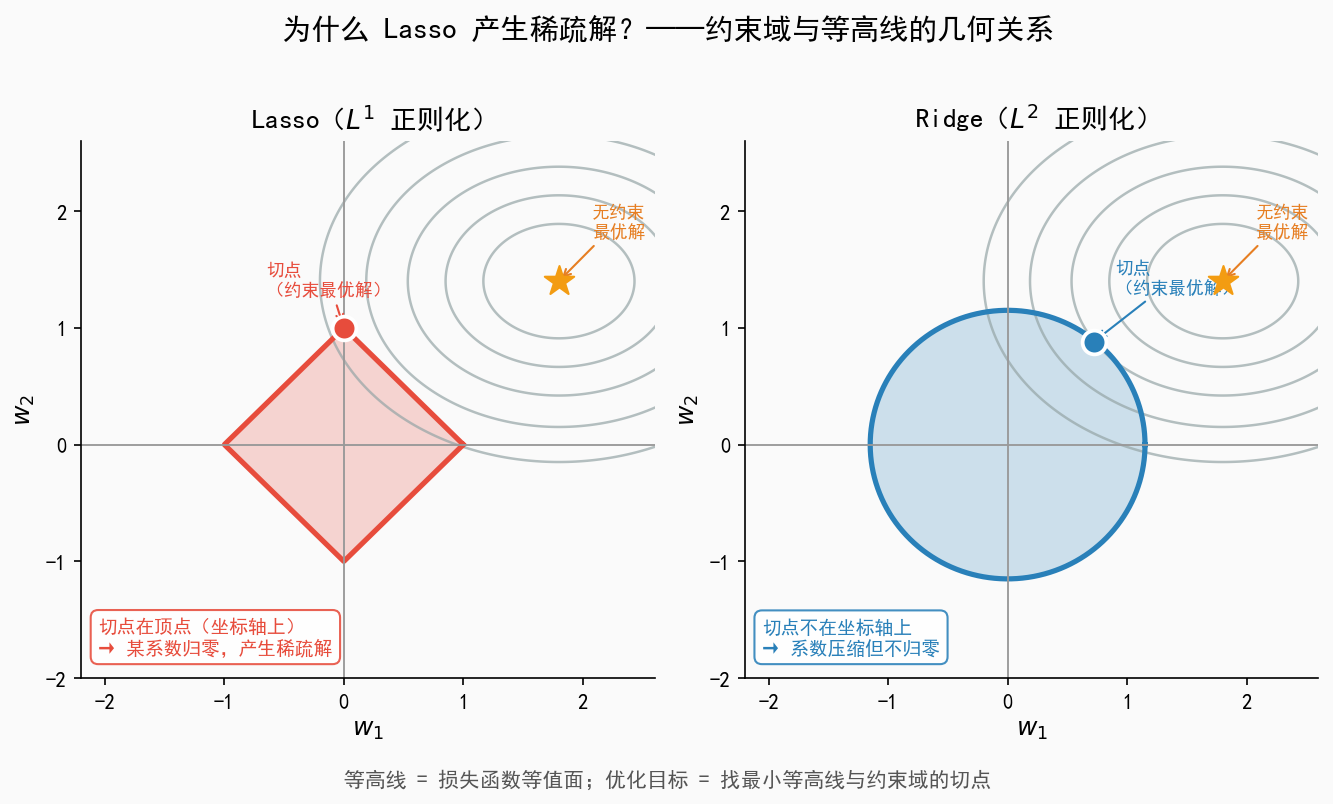

✓ 保存至 figures/lasso_ridge_geometry.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.9))
fig.patch.set_facecolor(C['bg'])

w1_opt, w2_opt = 1.8, 1.4
W1, W2 = np.meshgrid(np.linspace(-2.5, 2.8, 400), np.linspace(-2.5, 2.8, 400))
Z = (W1 - w1_opt)**2 / 1.0 + (W2 - w2_opt)**2 / 0.6

panel_configs = [
    ('Lasso（$L^1$ 正则化）', 1,   C['L1'],  1.0,  (0.0, 1.0),
     '切点在顶点（坐标轴上）\n→ 某系数归零，产生稀疏解'),
    ('Ridge（$L^2$ 正则化）', 2,   C['L2'],  1.15, (0.72, 0.88),
     '切点不在坐标轴上\n→ 系数压缩但不归零'),
]

for ax, (title, p, color, r, (tx, ty), insight) in zip(axes, panel_configs):
    ax.set_facecolor(C['bg'])

    ax.contour(W1, W2, Z, levels=[0.4, 0.9, 1.6, 2.6, 4.0],
               colors=C['contour'], linewidths=1.2, alpha=0.7)

    xc, yc = lp_unit_circle(p)
    ax.fill(xc * r, yc * r, alpha=0.22, color=color)
    ax.plot(xc * r, yc * r, color=color, linewidth=2.5)

    # 无约束最优解
    ax.scatter(w1_opt, w2_opt, marker='*', s=220, color='#F39C12', zorder=6)
    ax.annotate('无约束\n最优解', xy=(w1_opt, w2_opt),
                xytext=(w1_opt+0.28, w2_opt+0.38), fontsize=8.5, color='#E67E22',
                arrowprops=dict(arrowstyle='->', color='#E67E22', lw=1.0))

    # 切点
    ax.scatter(tx, ty, marker='o', s=130, color=color, zorder=7,
               edgecolors='white', linewidths=1.8)
    ox, oy = (-0.65, 0.28) if p == 1 else (0.18, 0.42)
    ax.annotate('切点\n（约束最优解）', xy=(tx, ty),
                xytext=(tx+ox, ty+oy), fontsize=8.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.0))

    ax.axhline(0, color='#999', lw=0.9)
    ax.axvline(0, color='#999', lw=0.9)
    ax.set_xlim(-2.2, 2.6); ax.set_ylim(-2.0, 2.6)
    ax.set_xlabel('$w_1$', fontsize=12); ax.set_ylabel('$w_2$', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.text(0.03, 0.04, insight, transform=ax.transAxes,
            fontsize=9, color=color, va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=color, alpha=0.88))
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

fig.suptitle('为什么 Lasso 产生稀疏解？——约束域与等高线的几何关系',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, -0.03,
         '等高线 = 损失函数等值面；优化目标 = 找最小等高线与约束域的切点',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.savefig('figures/lasso_ridge_geometry.png', dpi=150)
plt.show()
print("✓ 保存至 figures/lasso_ridge_geometry.png")


## 生成汇总

| 文件 | 对应 blog.md 位置 |
|------|-------------------|
| `figures/fig_distance_motivation.png` | 第一节：为什么要有距离 |
| `figures/fig_distance_paths.png`      | 第二节：三种经典距离 |
| `figures/fig_cosine.png`              | 第二节：余弦相似度 |
| `figures/norm_unit_balls.png`         | 第三节：三种范数的单位球 |
| `figures/lasso_ridge_geometry.png`    | 第四节：Lasso vs Ridge |


In [12]:
print("生成文件：")
for f in sorted(os.listdir('figures')):
    size = os.path.getsize(f'figures/{f}') // 1024
    print(f"  figures/{f}  ({size} KB)")
print("\n全部完成 ✓  将 figures/ 目录与 blog.md 放在同一文件夹即可正常显示图片。")


生成文件：
  figures/fig_cosine.png  (54 KB)
  figures/fig_distance_motivation.png  (116 KB)
  figures/fig_distance_paths.png  (66 KB)
  figures/lasso_ridge_geometry.png  (180 KB)
  figures/norm_unit_balls.png  (67 KB)

全部完成 ✓  将 figures/ 目录与 blog.md 放在同一文件夹即可正常显示图片。
